In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn


#### spliting our dataset to training and testing

### loading our dataset
you can download it here : https://www.kaggle.com/datasets/raphaelmanayon/temperature-and-ice-cream-sales

In [2]:
df=pd.read_csv("Ice Cream Sales - temperatures.csv")
df.dropna()
df.describe(),df.head(),df.shape

(       Temperature  Ice Cream Profits
 count   365.000000         365.000000
 mean     71.980822          52.103616
 std      13.258510          15.989004
 min      39.000000          11.880000
 25%      63.000000          40.650000
 50%      73.000000          53.620000
 75%      82.000000          63.630000
 max     101.000000          89.290000,
    Temperature  Ice Cream Profits
 0           39              13.17
 1           40              11.88
 2           41              18.82
 3           42              18.65
 4           43              17.02,
 (365, 2))

In [3]:
x = torch.tensor(df["Temperature"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["Ice Cream Profits"].values, dtype=torch.float32).unsqueeze(1)

### ploting our data

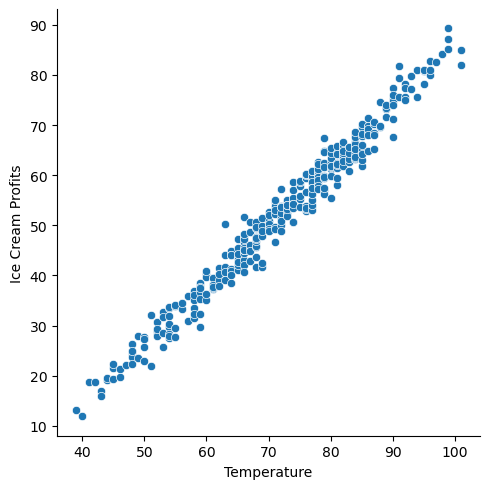

In [4]:
sns.relplot(data=df,x="Temperature",y="Ice Cream Profits")

### splitting our data to trainning and testing

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x.numpy(), y.numpy(), test_size=0.2, random_state=42
)
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test  = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

### build our model

In [36]:
model=nn.Linear(1,1)
#Define loss and optimizer
loss_fn=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.1)

### training loop

In [37]:
epoches=2000
for epoch in range(epoches):
    model.train()
    #forward
    y_pred=model(x_train)
    #loss
    loss=loss_fn(y_pred,y_train)
    #backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 42.0964
Epoch 100, Loss: 32.6368
Epoch 200, Loss: 23.1191
Epoch 300, Loss: 15.9882
Epoch 400, Loss: 11.3497
Epoch 500, Loss: 8.6328
Epoch 600, Loss: 7.1896
Epoch 700, Loss: 6.4944
Epoch 800, Loss: 6.1912
Epoch 900, Loss: 6.0718
Epoch 1000, Loss: 6.0293
Epoch 1100, Loss: 6.0158
Epoch 1200, Loss: 6.0119
Epoch 1300, Loss: 6.0109
Epoch 1400, Loss: 6.0106
Epoch 1500, Loss: 6.0106
Epoch 1600, Loss: 6.0106
Epoch 1700, Loss: 6.0106
Epoch 1800, Loss: 6.3719
Epoch 1900, Loss: 6.0106


In [38]:
model.eval()
with torch.inference_mode():
    y_test_pred = model(x_test)

test_loss = loss_fn(y_test_pred, y_test)
print("Test Loss:", test_loss.item())

Test Loss: 5.294124603271484
